In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os

ω0 = 1.0

downloads = os.path.join(os.path.expanduser("~"), "Downloads")

filename = os.path.join(downloads, "TC_Kac_OP_fock_c1.npz")

data = np.load(filename)

# extract arrays
N_arr = data["N"]
tau = data["tau"]
E_ergo = data["Eerg"]
E_var = data["variance"]
E_ratio = data["ratio"]
E_B = data["Eb"]
E_W2 = data["W2"]
Spin_Purity = data["spin_purity"]
PhotonMean = data["photon_mean"]
HighestOccupied = data["highest_occupied"]
EdgePopulation = data["edge_population"]

# derived quantities
Power = E_B / tau
E_max = ω0 * N_arr         # Largest battery energy

F_ratio = np.sqrt(E_var) / E_ergo
FE_ratio = np.sqrt(E_var) / E_B
S_ratio = E_W2 / E_B**2

In [2]:


for i in range(len(N_arr)):
    print(
        f"N={N_arr[i]}, "
        f"τ={tau[i]:.6f}, "
        f"Eb={E_B[i]:.6f}, "
        f"Ergotropy={E_ergo[i]:.6f}, "
        f"Second moment={E_W2[i]:.6f}, "
        f"Single-spin purity={Spin_Purity[i]:.6f}, "
        f"Ratio={E_ratio[i]:.6f}, "
        f"Variance={E_var[i]:.10e},"
        f"Fluctuation w.r.t erg={F_ratio[i]:.10e},"
        f"Fluctuation w.r.t EB={FE_ratio[i]:.10e}"
    )

N=2, τ=10.811703, Eb=1.355722, Ergotropy=0.945207, Second moment=1.054793, Single-spin purity=0.563269, Ratio=0.697198, Variance=1.6137615538e-01,Fluctuation w.r.t erg=4.2500365226e-01,Fluctuation w.r.t EB=2.9631179674e-01
N=4, τ=10.711604, Eb=2.574393, Ergotropy=1.929524, Second moment=5.182564, Single-spin purity=0.541241, Ratio=0.749506, Variance=1.4595003601e+00,Fluctuation w.r.t erg=6.2611181736e-01,Fluctuation w.r.t EB=4.6927476312e-01
N=6, τ=10.711604, Eb=3.817476, Ergotropy=3.033760, Second moment=10.546527, Single-spin purity=0.537126, Ratio=0.794703, Variance=1.3428268062e+00,Fluctuation w.r.t erg=3.8196957259e-01,Fluctuation w.r.t EB=3.0355241588e-01
N=8, τ=10.811703, Eb=5.110405, Ergotropy=4.161791, Second moment=19.481375, Single-spin purity=0.538531, Ratio=0.814376, Variance=2.1608671103e+00,Fluctuation w.r.t erg=3.5321059019e-01,Fluctuation w.r.t EB=2.8764622956e-01
N=10, τ=10.811703, Eb=6.368742, Ergotropy=5.272716, Second moment=29.598094, Single-spin purity=0.537469, 

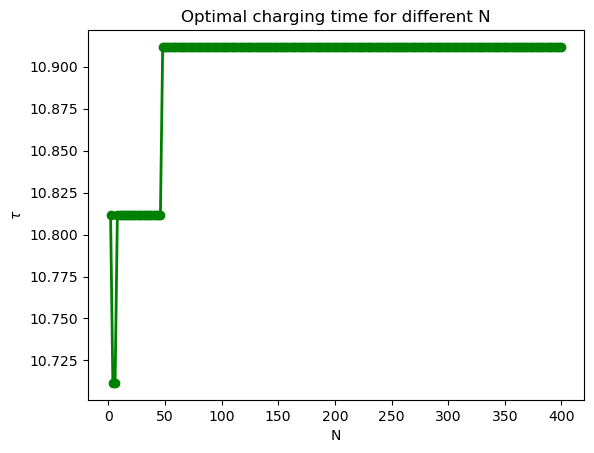

In [3]:
###############################################################
# Plot of battery optimal charging time for different N 
###############################################################

plt.plot(N_arr, tau, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\tau$")
plt.title("Optimal charging time for different N")
plt.show()

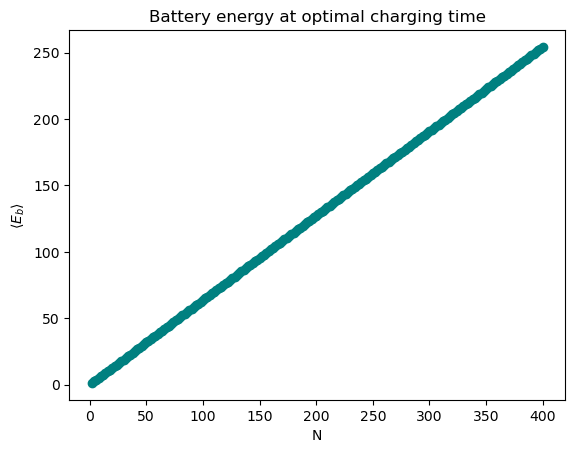

In [4]:
###############################################################
# Plot of battery energy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_B, 'o-', color='teal', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$ \langle E_{b} \rangle $")
plt.title("Battery energy at optimal charging time")
plt.show()

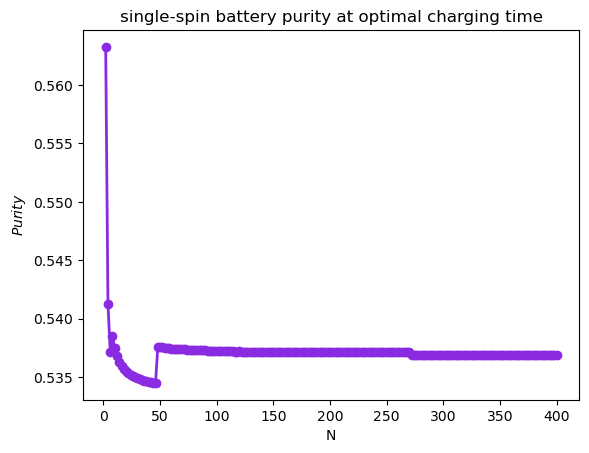

In [5]:
##########################################################################
# Plot of single-spin battery purity at optimal charging for different N 
##########################################################################

plt.plot(N_arr, Spin_Purity, 'o-', color='blueviolet', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$ Purity $")
plt.title("single-spin battery purity at optimal charging time")
plt.show()


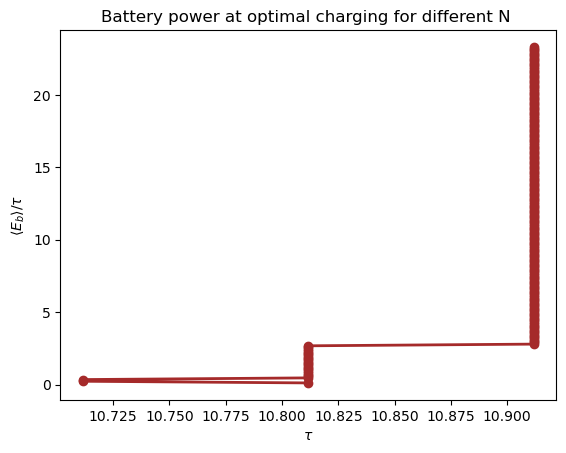

In [6]:
############################################################
# Plot of battery power at optimal charging for different N 
############################################################

plt.plot(tau, Power, 'o-', color='brown', linewidth=2)
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_b \rangle / \tau$")
plt.title(f"Battery power at optimal charging for different N ")
plt.show()

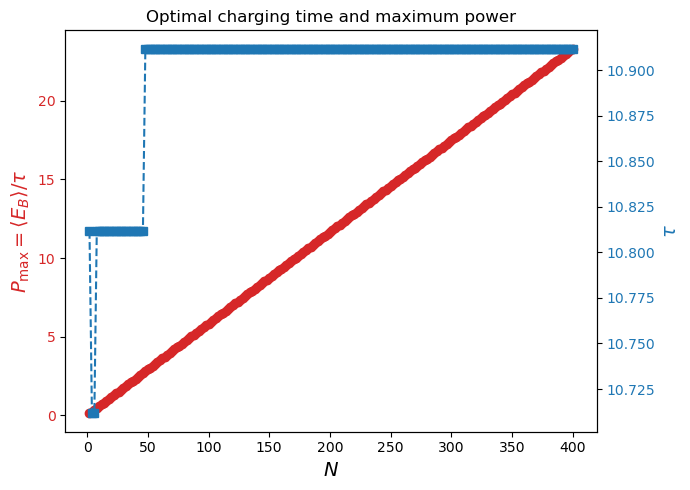

In [7]:
#####################################################################
# Plot of battery optimal charging and maximum power for different N 
#####################################################################

fig, ax1 = plt.subplots(figsize=(7,5))

ax1.plot(N_arr, Power, 'o-', color='tab:red', label='Power')
ax1.set_xlabel(r'$N$', fontsize=14)
ax1.set_ylabel(r'$P_{\max}=\langle E_B\rangle/\tau$', color='tab:red', fontsize=14)
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()

ax2.plot(N_arr, tau, 's--', color='tab:blue', label=r'$\tau$')
ax2.set_ylabel(r'$\tau$', color='tab:blue', fontsize=14)
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Optimal charging time and maximum power')
plt.tight_layout()
plt.show()

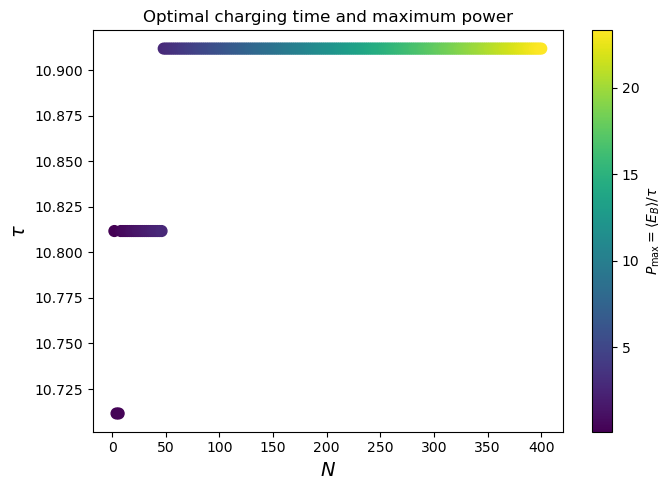

In [8]:

#####################################################################
# Plot of battery optimal charging and maximum power for different N 
#####################################################################

plt.figure(figsize=(7,5))

sc = plt.scatter(
    N_arr,
    tau,
    c=Power,
    cmap='viridis',
    s=60
)

plt.xlabel(r'$N$', fontsize=14)
plt.ylabel(r'$\tau$', fontsize=14)

cbar = plt.colorbar(sc)
cbar.set_label(r'$P_{\max}=\langle E_B\rangle/\tau$')

plt.title('Optimal charging time and maximum power')
plt.tight_layout()
plt.show()

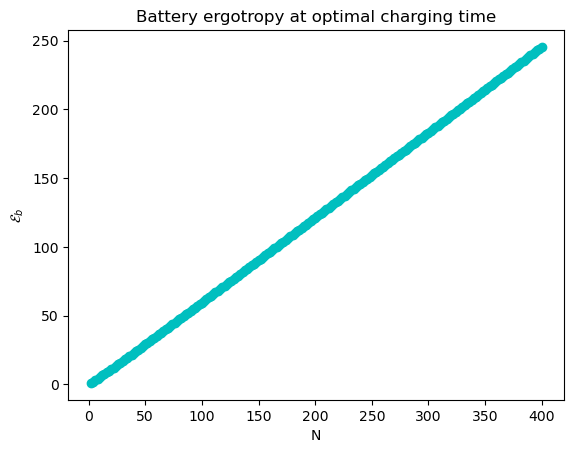

In [9]:
###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

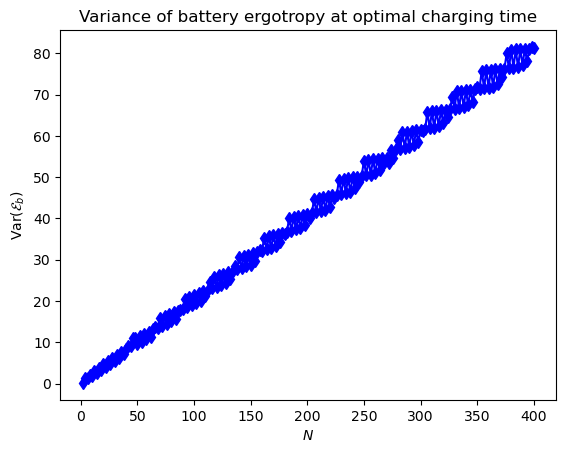

In [10]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

### Scaling of $1 - \mathcal{E}_b / \langle E_b \rangle$

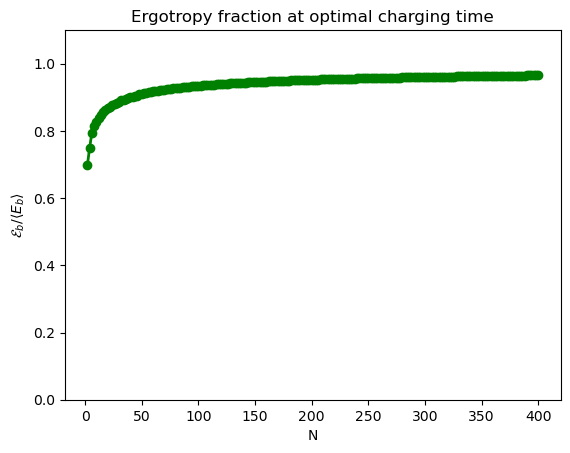

In [11]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

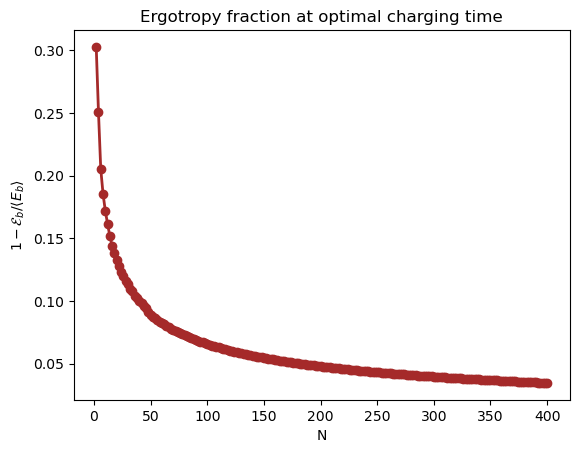

In [12]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, 1 - E_ratio, 'o-', color='brown', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

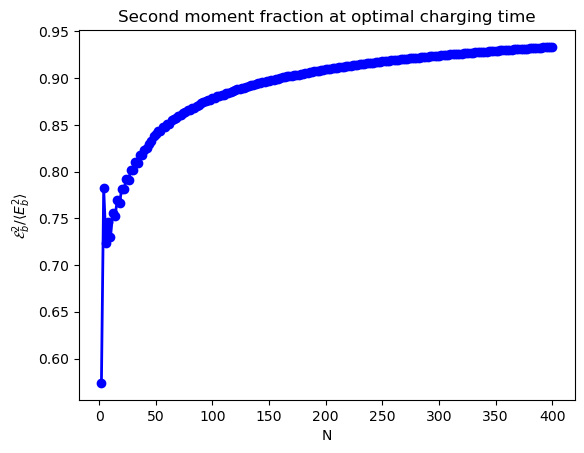

In [13]:
#################################################################
# Plot second moment fraction as a function of g for different N 
#################################################################

plt.plot(N_arr, S_ratio, 'o-', color='blue', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b^{2}/ \langle E_b^{2} \rangle$")
plt.title("Second moment fraction at optimal charging time")
plt.show()

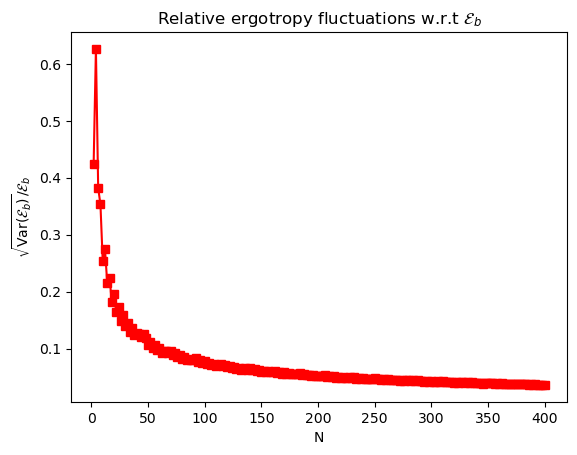

In [14]:
######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.show()

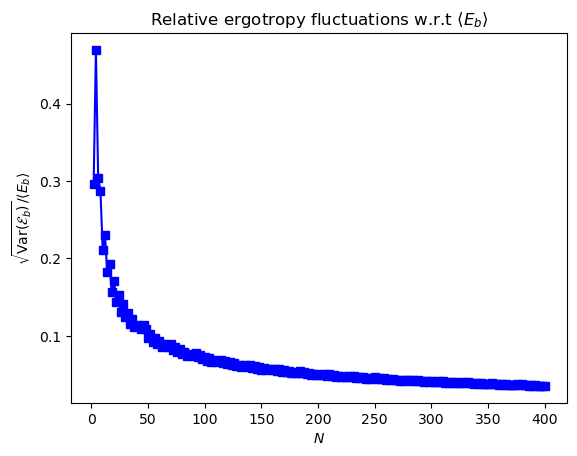

In [15]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()

### Scaling of $ 1 - \mathcal{E}_b/\langle{E}_b \rangle $

Range [110:200] (N range: 222 to 400)  -->  alpha = 0.467460
Range [120:200] (N range: 242 to 400)  -->  alpha = 0.468182
Range [130:200] (N range: 262 to 400)  -->  alpha = 0.469625
Range [140:200] (N range: 282 to 400)  -->  alpha = 0.471176
Range [150:200] (N range: 302 to 400)  -->  alpha = 0.471887
Range [160:200] (N range: 322 to 400)  -->  alpha = 0.472156
Range [170:200] (N range: 342 to 400)  -->  alpha = 0.472802
Range [180:200] (N range: 362 to 400)  -->  alpha = 0.472808
Range [190:200] (N range: 382 to 400)  -->  alpha = 0.470554


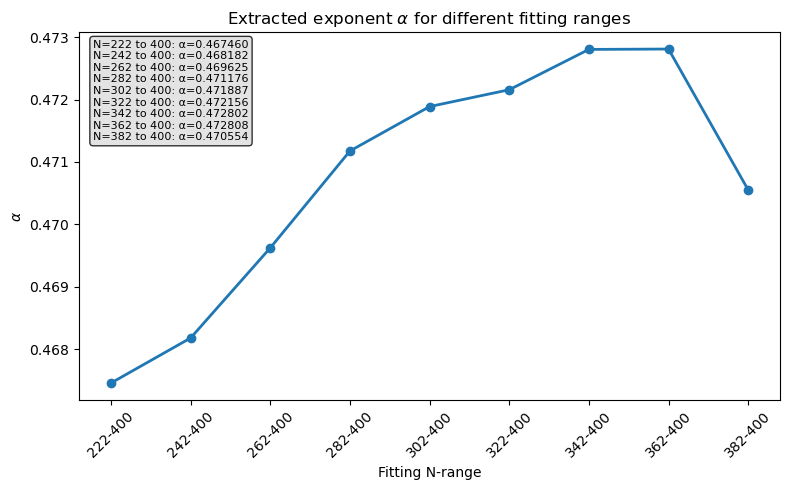

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def log_fit1(log_N, logA, alpha):
    return logA - alpha * log_N

y_full = 1 - np.array(E_ratio)

fit_ranges = [
    (110, 200),
    (120, 200),
    (130, 200),
    (140, 200),
    (150, 200),
    (160, 200),
    (170, 200),
    (180, 200),
    (190, 200)
]

alpha_list = []
range_labels = []

for start, end in fit_ranges:
    N_data = N_arr[start:end]
    y_data = y_full[start:end]

    mask = (N_data > 0) & (y_data > 0)

    N_fit = N_data[mask]
    y_fit = y_data[mask]

    if len(N_fit) < 3:
        print(f"Skipping range [{start}:{end}] because it contains only {len(N_fit)} elements.")
        continue

    log_N = np.log(N_fit)
    log_y = np.log(y_fit)

    popt, _ = curve_fit(log_fit1, log_N, log_y)
    alpha = popt[1]

    alpha_list.append(alpha)
    range_labels.append(f"{start}:{end}")

    print(f"Range [{start}:{end}] (N range: {N_fit[0]} to {N_fit[-1]})  -->  alpha = {alpha:.6f}")

# -----------------------------------
# Alpha vs fitting range Plot
# -----------------------------------
plt.figure(figsize=(8,5))

alpha_text = "\n".join(
    [f"N={N_arr[s]} to {N_arr[e-1]}: α={a:.6f}"
     for (s, e), a in zip(fit_ranges, alpha_list)]
)


plt.text(
    0.02, 0.98,
    alpha_text,
    transform=plt.gca().transAxes,
    fontsize=8,
    va='top',
    bbox=dict(boxstyle='round', facecolor='gainsboro', alpha=0.8)
)

xvals = np.arange(len(alpha_list))

xticklabels = [
    f"{N_arr[s]}-{N_arr[e-1]}"
    for s, e in fit_ranges
]

plt.plot(xvals, alpha_list, 'o-', lw=2, color='tab:blue')
plt.xticks(xvals, xticklabels, rotation=45)
plt.xlabel("Fitting N-range")
plt.ylabel(r"$\alpha$")
plt.title(r"Extracted exponent $\alpha$ for different fitting ranges")

plt.tight_layout()
plt.show()

Best fit parameter: A = 0.585058, alpha = 0.472156


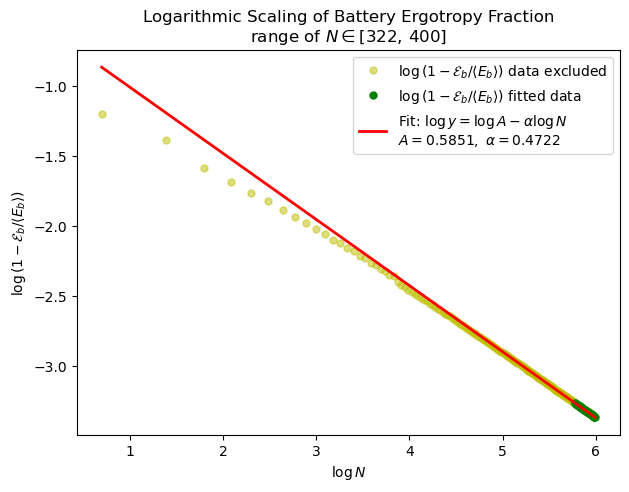

In [17]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit1(log_N, logA, alpha1):
    return logA - alpha1 *log_N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data1 = N_arr[160:200]
y_data1 = y_full[160:200]

# Keep only positive values for the logarithm
mask = (N_data1 > 0) & (y_data1 > 0)

N_fit1 = N_data1[mask]
y_fit_data1 = y_data1[mask]

# Logarithmic variables
log_N = np.log(N_fit1)
log_y = np.log(y_fit_data1)

# Fit in log-space
popt, pcov = curve_fit(log_fit1, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title(
    rf"Logarithmic Scaling of Battery Ergotropy Fraction"
    "\n"
    rf"range of $N \in [{N_fit1[0]},\, {N_fit1[-1]}]$"
)
plt.legend()
plt.show()

### Scaling of $\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$

Range [110:200] (N range: 222 to 400)  -->  alpha = 0.516065
Range [120:200] (N range: 242 to 400)  -->  alpha = 0.510826
Range [130:200] (N range: 262 to 400)  -->  alpha = 0.511066
Range [140:200] (N range: 282 to 400)  -->  alpha = 0.520411
Range [150:200] (N range: 302 to 400)  -->  alpha = 0.525665
Range [160:200] (N range: 322 to 400)  -->  alpha = 0.529454
Range [170:200] (N range: 342 to 400)  -->  alpha = 0.509999
Range [180:200] (N range: 362 to 400)  -->  alpha = 0.537710
Range [190:200] (N range: 382 to 400)  -->  alpha = 0.534583


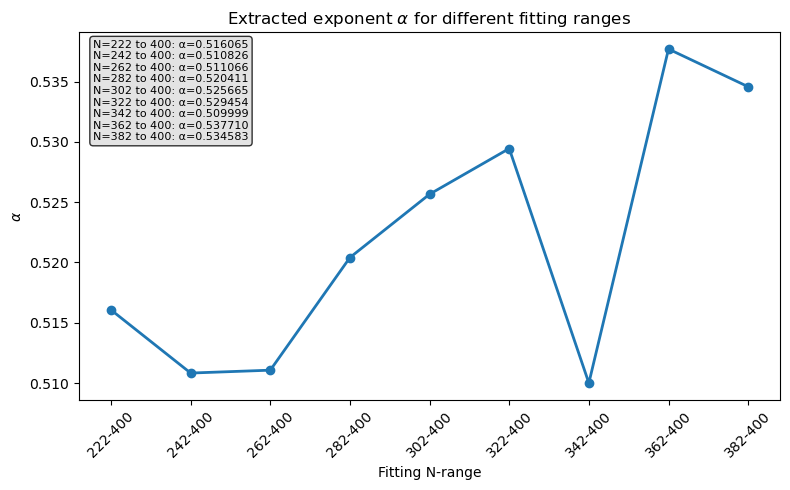

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def log_fit2(log_N, logA, alpha):
    return logA - alpha * log_N

y_full = np.array(F_ratio)

fit_ranges = [
    (110, 200),
    (120, 200),
    (130, 200),
    (140, 200),
    (150, 200),
    (160, 200),
    (170, 200),
    (180, 200),
    (190, 200)
]

alpha_list = []
range_labels = []

for start, end in fit_ranges:
    N_data = N_arr[start:end]
    y_data = y_full[start:end]

    mask = (N_data > 0) & (y_data > 0)

    N_fit = N_data[mask]
    y_fit = y_data[mask]

    if len(N_fit) < 3:
        print(f"Skipping range [{start}:{end}] because it contains only {len(N_fit)} elements.")
        continue

    log_N = np.log(N_fit)
    log_y = np.log(y_fit)

    popt, _ = curve_fit(log_fit2, log_N, log_y)
    alpha = popt[1]

    alpha_list.append(alpha)
    range_labels.append(f"{start}:{end}")

    print(f"Range [{start}:{end}] (N range: {N_fit[0]} to {N_fit[-1]})  -->  alpha = {alpha:.6f}")

# -----------------------------------
# Alpha vs fitting range Plot
# -----------------------------------
plt.figure(figsize=(8,5))

alpha_text = "\n".join(
    [f"N={N_arr[s]} to {N_arr[e-1]}: α={a:.6f}"
     for (s, e), a in zip(fit_ranges, alpha_list)]
)


plt.text(
    0.02, 0.98,
    alpha_text,
    transform=plt.gca().transAxes,
    fontsize=8,
    va='top',
    bbox=dict(boxstyle='round', facecolor='gainsboro', alpha=0.8)
)

xvals = np.arange(len(alpha_list))

xticklabels = [
    f"{N_arr[s]}-{N_arr[e-1]}"
    for s, e in fit_ranges
]

plt.plot(xvals, alpha_list, 'o-', lw=2, color='tab:blue')
plt.xticks(xvals, xticklabels, rotation=45)
plt.xlabel("Fitting N-range")
plt.ylabel(r"$\alpha$")
plt.title(r"Extracted exponent $\alpha$ for different fitting ranges")

plt.tight_layout()
plt.show()

Best fit parameter: A = 0.877606, alpha = 0.529454


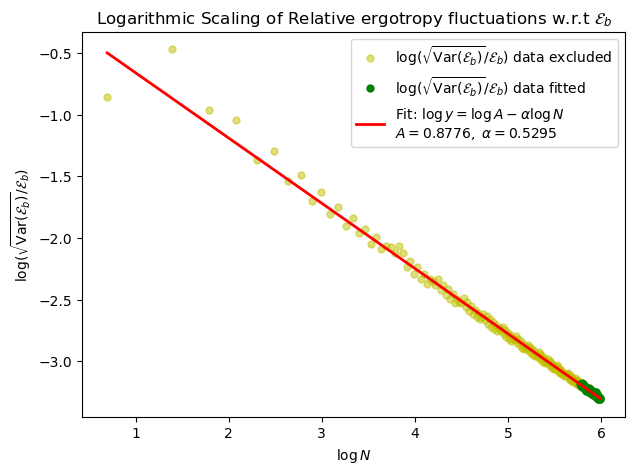

In [19]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit2(log_N, logA, alpha2):
    return logA - alpha2 *log_N

y_full = np.array(F_ratio)

# Restrict fitting data
N_data2 = N_arr[160:200]
y_data2 = y_full[160:200]

# Keep only positive values for the logarithm
mask = (N_data2 > 0) & (y_data2 > 0)

N_fit2 = N_data2[mask]
y_fit_data2 = y_data2[mask]

# Logarithmic variables
log_N = np.log(N_fit2)
log_y = np.log(y_fit_data2)

# Fit in log-space
popt, pcov = curve_fit(log_fit2, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log (\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log (\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b)$ data fitted")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log A - \alpha \log N$'
        '\n'
        rf'$A={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log (\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b)$")
plt.title(r"Logarithmic Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
plt.show()

### Scaling of $ \mathcal{E}_b^{2}/ \langle E_b^{2} \rangle - 1 $

Range [110:200] (N range: 222 to 400)  -->  alpha = -0.036614
Range [120:200] (N range: 242 to 400)  -->  alpha = -0.036013
Range [130:200] (N range: 262 to 400)  -->  alpha = -0.035507
Range [140:200] (N range: 282 to 400)  -->  alpha = -0.035020
Range [150:200] (N range: 302 to 400)  -->  alpha = -0.034522
Range [160:200] (N range: 322 to 400)  -->  alpha = -0.034033
Range [170:200] (N range: 342 to 400)  -->  alpha = -0.033680
Range [180:200] (N range: 362 to 400)  -->  alpha = -0.033156
Range [190:200] (N range: 382 to 400)  -->  alpha = -0.032582


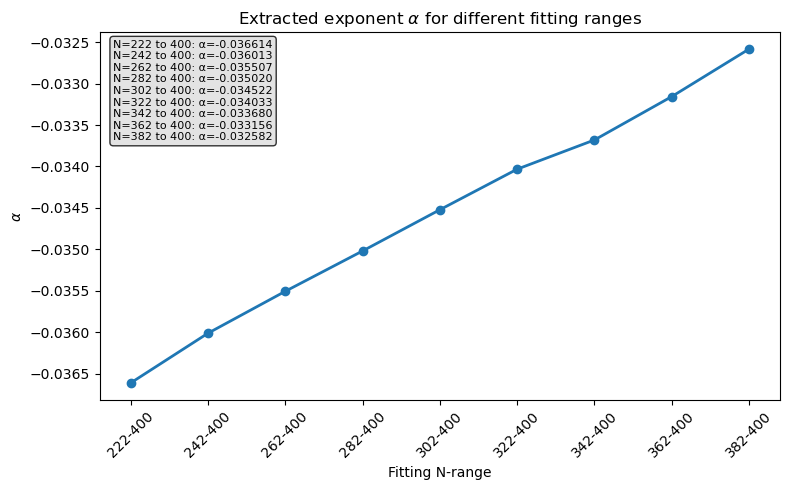

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def log_fit3(log_N, logA, alpha3):
    return logA - alpha3 *log_N

y_full = np.array(S_ratio)

fit_ranges = [
    (110, 200),
    (120, 200),
    (130, 200),
    (140, 200),
    (150, 200),
    (160, 200),
    (170, 200),
    (180, 200),
    (190, 200)
]

alpha_list = []
range_labels = []

for start, end in fit_ranges:
    N_data = N_arr[start:end]
    y_data = y_full[start:end]

    mask = (N_data > 0) & (y_data > 0)

    N_fit = N_data[mask]
    y_fit = y_data[mask]

    if len(N_fit) < 3:
        print(f"Skipping range [{start}:{end}] because it contains only {len(N_fit)} elements.")
        continue

    log_N = np.log(N_fit)
    log_y = np.log(y_fit)

    popt, _ = curve_fit(log_fit3, log_N, log_y)
    alpha3 = popt[1]

    alpha_list.append(alpha3)
    range_labels.append(f"{start}:{end}")

    print(f"Range [{start}:{end}] (N range: {N_fit[0]} to {N_fit[-1]})  -->  alpha = {alpha3:.6f}")

# -----------------------------------
# Alpha vs fitting range Plot
# -----------------------------------
plt.figure(figsize=(8,5))

alpha_text = "\n".join(
    [f"N={N_arr[s]} to {N_arr[e-1]}: α={a:.6f}"
     for (s, e), a in zip(fit_ranges, alpha_list)]
)


plt.text(
    0.02, 0.98,
    alpha_text,
    transform=plt.gca().transAxes,
    fontsize=8,
    va='top',
    bbox=dict(boxstyle='round', facecolor='gainsboro', alpha=0.8)
)

xvals = np.arange(len(alpha_list))

xticklabels = [
    f"{N_arr[s]}-{N_arr[e-1]}"
    for s, e in fit_ranges
]

plt.plot(xvals, alpha_list, 'o-', lw=2, color='tab:blue')
plt.xticks(xvals, xticklabels, rotation=45)
plt.xlabel("Fitting N-range")
plt.ylabel(r"$\alpha$")
plt.title(r"Extracted exponent $\alpha$ for different fitting ranges")

plt.tight_layout()
plt.show()

Best fit parameter: A = 0.761210, alpha = -0.034033


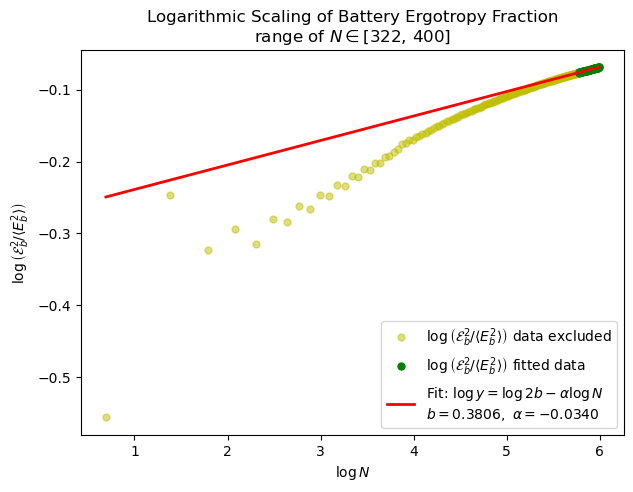

In [21]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit3(log_N, logA, alpha3):
    return logA - alpha3 *log_N

y_full = np.array(S_ratio)

# Restrict fitting data
N_data3 = N_arr[160:200]
y_data3 = y_full[160:200]

# Keep only positive values for the logarithm
mask = (N_data3 > 0) & (y_data3 > 0)

N_fit3 = N_data3[mask]
y_fit_data3 = y_data3[mask]

# Logarithmic variables
log_N = np.log(N_fit3)
log_y = np.log(y_fit_data3)

# Fit in log-space
popt, pcov = curve_fit(log_fit3, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(\mathcal{E}_b^{2}/ \langle E_b^{2} \rangle \right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(\mathcal{E}_b^{2}/ \langle E_b^{2} \rangle \right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \log 2b - \alpha \log N$'
        '\n'
        rf'$b={A_opt/2:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(\mathcal{E}_b^{2}/ \langle E_b^{2} \rangle \right)$")
plt.title(
    rf"Logarithmic Scaling of Battery Ergotropy Fraction"
    "\n"
    rf"range of $N \in [{N_fit3[0]},\, {N_fit3[-1]}]$"
)
plt.legend()
plt.show()

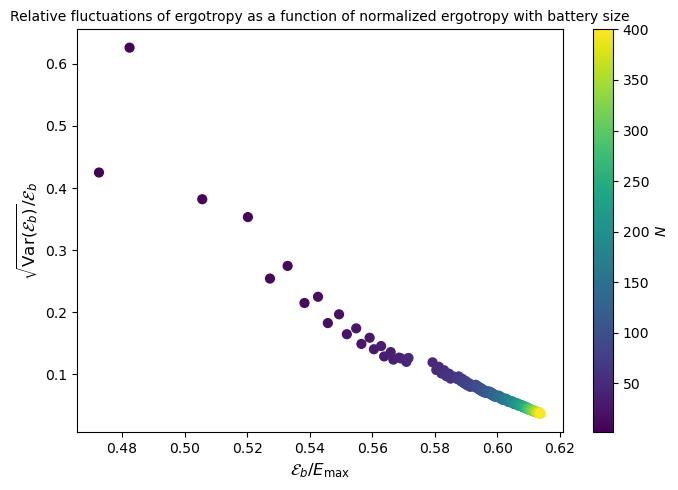

In [22]:
####################################################################################################
# Plot of relative fluctuations of ergotropy as a function of normalized ergotropy with different N
####################################################################################################

plt.figure(figsize=(7, 5))

sc = plt.scatter(E_ergo / E_max,
                 F_ratio,
                 c=N_arr,
                 cmap='viridis',
                 s=40
                 )

plt.xlabel(r'$\mathcal{E}_b/E_{\max}$', fontsize=12)
plt.ylabel(r'$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$', fontsize=12)
plt.title("Relative fluctuations of ergotropy as a function of normalized ergotropy with battery size", fontsize=10)

cbar = plt.colorbar(sc)
cbar.set_label(r'$N$')

plt.tight_layout()
plt.show()

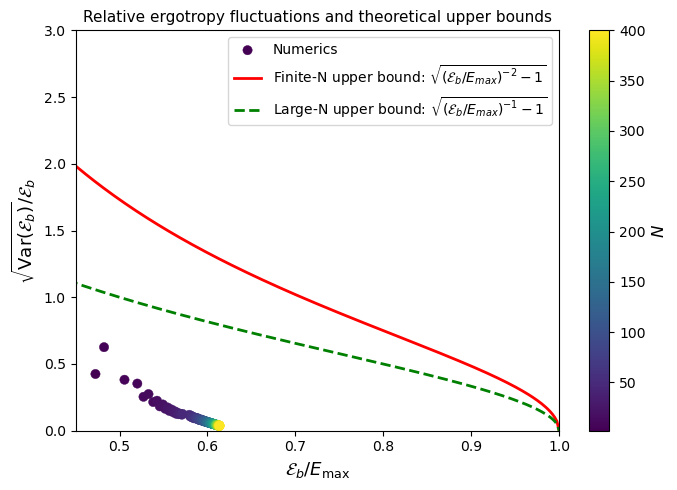

In [23]:
##########################################################
# Relative ergotropy fluctuations vs normalized ergotropy
##########################################################

# Numerical data
x = E_ergo / E_max
y = F_ratio

# Domain for theoretical bounds
xb = np.linspace(0.01, 1.0, 400)

# Upper bounds 
bound_finite = np.sqrt(1/xb**2 - 1)      # finite-N
bound_largeN = np.sqrt(1/xb - 1)         # large-N 

plt.figure(figsize=(7,5))

# Numerical results
sc = plt.scatter(
    x,
    y,
    c=N_arr,
    cmap='viridis',
    s=45,
    linewidth=0.3,
    label='Numerics'
)

# Finite-N upper bound
plt.plot(
    xb,
    bound_finite,
    'r-',
    lw=2,
    label=r'Finite-N upper bound: $\sqrt{({\mathcal{E}_b/E_{max}})^{-2} -1}$'
)

# Large-N upper bound
plt.plot(
    xb,
    bound_largeN,
    'g--',
    lw=2,
    label=r'Large-N upper bound: $\sqrt{({\mathcal{E}_b/E_{max}})^{-1} -1}$'
)

plt.xlim(0.45,1.0)
plt.ylim(0,3)

plt.xlabel(r'$\mathcal{E}_b/E_{\max}$', fontsize=13)
plt.ylabel(r'$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$', fontsize=13)

plt.title("Relative ergotropy fluctuations and theoretical upper bounds", fontsize=11)

cbar = plt.colorbar(sc)
cbar.set_label(r'$N$', fontsize=12)

plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

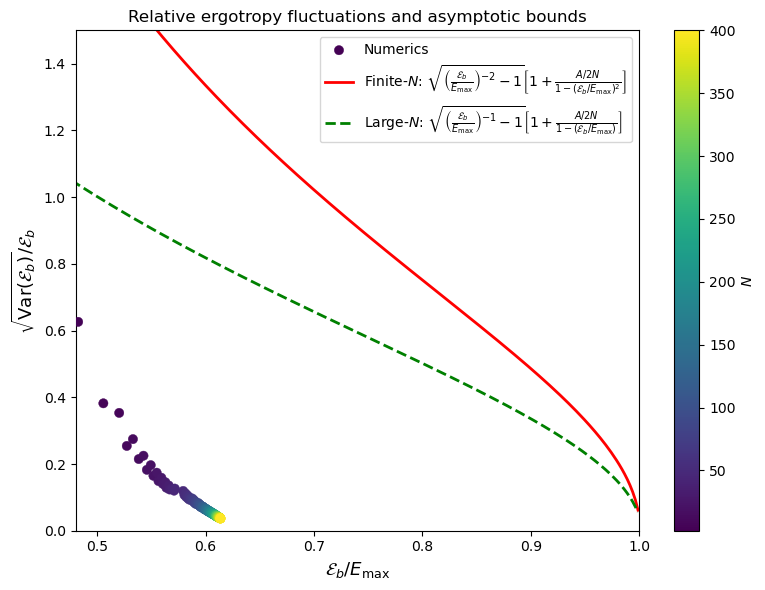

In [24]:
###############################################################################################
# Relative ergotropy fluctuations vs normalized ergotropy with asymptotic finite-N corrections
###############################################################################################

a = 0.600707    # replaced by fitted value 

x = E_ergo / E_max
y = F_ratio

xb = np.linspace(0.01,0.999,400)

# Eq.(11) asymptotic correction
bound1 = np.sqrt(1/xb**2 - 1) * (
    1 + 0.5*a/(1-xb**2)/N_arr.max()
)

# Eq.(15) asymptotic correction
bound2 = np.sqrt(1/xb - 1) * (
    1 + 0.5*a/(1-xb)/N_arr.max()
)

plt.figure(figsize=(8,6))

sc = plt.scatter(
    x,
    y,
    c=N_arr,
    cmap='viridis',
    s=45,
    linewidth=0.3,
    zorder=3,
    label='Numerics'
)

plt.plot(
    xb,
    bound1,
    'r-',
    lw=2,
    label=r'Finite-$N$: $\sqrt{\left(\frac{\mathcal{E}_b}{E_{\max}}\right)^{-2}-1}\left[1+\frac{A/2N}{1-(\mathcal{E}_b/E_{\max})^2}\right]$'
)

plt.plot(
    xb,
    bound2,
    'g--',
    lw=2,
    label=r'Large-$N$: $\sqrt{\left(\frac{\mathcal{E}_b}{E_{\max}}\right)^{-1}-1}\left[1+\frac{A/2N}{1-(\mathcal{E}_b/E_{\max})}\right]$'
)

plt.xlabel(r'$\mathcal{E}_b/E_{\max}$', fontsize=13)
plt.ylabel(r'$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$', fontsize=13)

plt.xlim(0.48,1.0)
plt.ylim(0,1.5)

plt.title("Relative ergotropy fluctuations and asymptotic bounds")

cbar = plt.colorbar(sc)
cbar.set_label(r'$N$')

plt.legend()
plt.tight_layout()
plt.show()

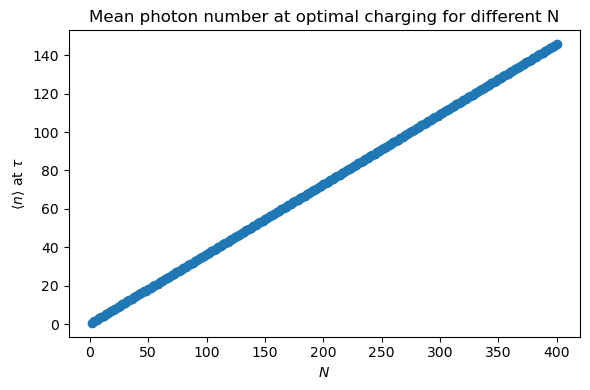

In [25]:
################################################################
# Plot of mean photon number at optimal charging for different N
################################################################

plt.figure(figsize=(6,4))
plt.plot(N_arr, PhotonMean, 'o-')
plt.xlabel(r'$N$')
plt.ylabel(r'$\langle n\rangle$ at $\tau$')
plt.title("Mean photon number at optimal charging for different N")
plt.tight_layout()
plt.show()

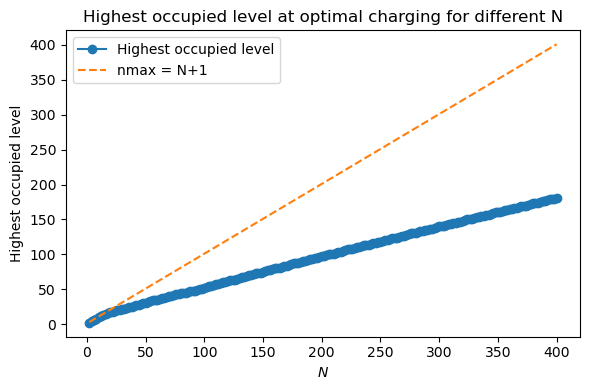

In [26]:
#####################################################################
# Plot of highest occupied level at optimal charging for different N
#####################################################################

plt.figure(figsize=(6,4))
plt.plot(N_arr, HighestOccupied, 'o-', label='Highest occupied level')
plt.plot(N_arr, N_arr+1, '--', label='nmax = N+1')
plt.xlabel(r'$N$')
plt.ylabel('Highest occupied level')
plt.title("Highest occupied level at optimal charging for different N")
plt.legend()
plt.tight_layout()
plt.show()

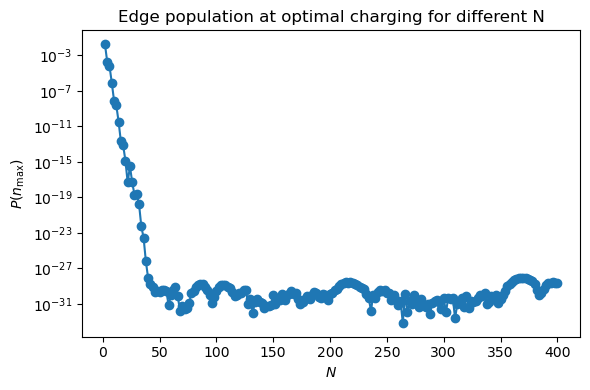

In [27]:
##############################################################
# Plot of edge population at optimal charging for different N
##############################################################

plt.figure(figsize=(6,4))
plt.semilogy(N_arr, EdgePopulation, 'o-')
plt.xlabel(r'$N$')
plt.ylabel(r'$P(n_{\max})$')
plt.title("Edge population at optimal charging for different N")
plt.tight_layout()
plt.show()

Best fit parameter: A = 0.641637, alpha = 0.998441


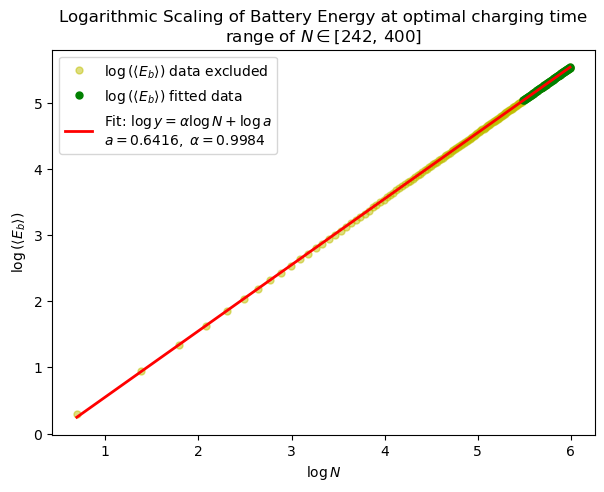

In [28]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit3(log_N, logA, alpha3):
    return  alpha3 *log_N + logA

y_full = np.array(E_B)

# Restrict fitting data
N_data3 = N_arr[120:200]
y_data3 = y_full[120:200]

# Keep only positive values for the logarithm
mask = (N_data3 > 0) & (y_data3 > 0)

N_fit3 = N_data3[mask]
y_fit_data3 = y_data3[mask]

# Logarithmic variables
log_N = np.log(N_fit3)
log_y = np.log(y_fit_data3)

# Fit in log-space
popt, pcov = curve_fit(log_fit3, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 150)

y_smooth = A_opt * (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(\langle E_b \rangle \right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(\langle E_b \rangle \right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=(
        rf'Fit: $\log y = \alpha \log N + \log a$'
        '\n'
        rf'$a={A_opt:.4f},\ \alpha={alpha_opt:.4f}$'))

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(\langle E_b \rangle \right)$")
plt.title(
    rf"Logarithmic Scaling of Battery Energy at optimal charging time"
    "\n"
    rf"range of $N \in [{N_fit3[0]},\, {N_fit3[-1]}]$"
)
plt.legend()
plt.show()

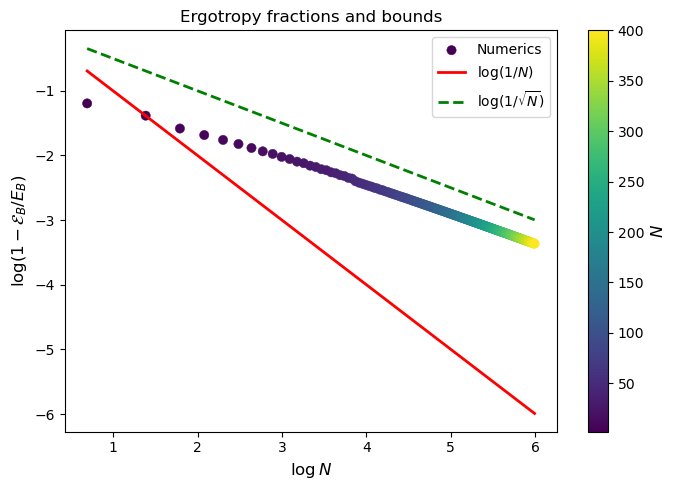

In [29]:
####################################
# Ergotropy fractions and bounds 
####################################

# Numerical data
x = np.log(N_arr)
y = np.log(1 - E_ratio)

# Domain for bounds
Nb = np.logspace(np.log10(np.min(N_arr)),
                 np.log10(np.max(N_arr)), 400)

xb = np.log(Nb)

# Bounds in log coordinates
bound_1 = -xb                 # log(1/N)
bound_2 = -0.5 * xb           # log(1/sqrt(N))

plt.figure(figsize=(7,5))

sc = plt.scatter(
    x, y,
    c=N_arr,
    cmap='viridis',
    s=45,
    linewidth=0.3,
    label='Numerics'
)

plt.plot(xb, bound_1, 'r-', lw=2, label=r'$\log(1/N)$')
plt.plot(xb, bound_2, 'g--', lw=2, label=r'$\log(1/\sqrt{N})$')


plt.xlabel(r'$\log N$', fontsize=12)
plt.ylabel(r'$\log(1-\mathcal{E}_B/E_B)$', fontsize=12)

plt.title("Ergotropy fractions and bounds", fontsize=12)

cbar = plt.colorbar(sc)
cbar.set_label(r'$N$', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()